<a href="https://colab.research.google.com/github/AlissonValencia/IA_practicas/blob/main/ia_practica2_Valencia_Larrea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

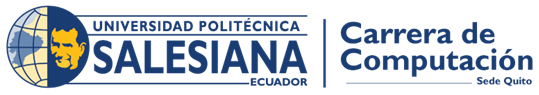

***ACTIVIDADES A DESARROLLAR:***

## **Clasificador con Naives Bayes**

Nombre: Alisson Valencia

Materia: Inteligencia Artificial

Práctica: 2

---

#***ACTIVIDADES A DESARROLLAR:***

Antes de construir cualquier modelo de Aprendizaje de Máquina, es fundamental entender los datos. Un modelo entrenado sobre datos mal comprendidos producirá resultados que no podrás interpretar ni confiar.

#***Fase 1. Exploración del Dataset***

En esta práctica trabajarás con el dataset Amazon Reviews Multilingual [1], que contiene reseñas de productos en múltiples idiomas. Usarás el subconjunto en español, que incluye reseñas etiquetadas con una calificación de 1 a 5 estrellas. Tu tarea será construir un clasificador que determine si una reseña expresa sentimiento positivo (4–5 ⭐ ) o negativo (1–2 ).

**1.1 Carga del Dataset**

Ejecuta el siguiente bloque para instalar las dependencias y cargar los datos. Esta es la única celda que se te proporciona completa, a partir de aquí, tú construyes el resto de la práctica.

In [ ]:
# Instalación (solo necesaria en Colab)
!pip install datasets -q

from datasets import load_dataset
import pandas as pd

dataset = load_dataset("SetFit/amazon_reviews_multi_es")
df_train = dataset["train"].to_pandas()
df_test  = dataset["test"].to_pandas()

# Renombrar columnas para mantener consistencia con el resto de la práctica
df_train = df_train.rename(columns={"text": "review_body", "label": "stars"})
df_test  = df_test.rename(columns={"text": "review_body", "label": "stars"})

# Ajustar escala: label va de 0-4, lo convertimos a 1-5
df_train["stars"] = df_train["stars"] + 1
df_test["stars"]  = df_test["stars"] + 1

print(f"Entrenamiento: {len(df_train):,} reseñas")
print(f"Prueba:        {len(df_test):,} reseñas")
print(f"\nColumnas: {df_train.columns.tolist()}")
print(f"""\nDistribución de estrellas:
{df_train['stars'].value_counts().sort_index()}""")
df_train.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/310 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/43.8M [00:00<?, ?B/s]

validation.jsonl: 0.00B [00:00, ?B/s]

...

Generating train split:   0%|          | 0/200000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Entrenamiento: 200,000 reseñas
Prueba:        5,000 reseñas

Columnas: ['id', 'review_body', 'stars', 'label_text']

Distribución de estrellas:
stars
1    40000
2    40000
3    40000
4    40000
5    40000
Name: count, dtype: int64


,id,review_body,stars,label_text
0,es_0491108,Nada bueno se me fue ka pantalla en menos de 8...,1,0
1,es_0869872,"Horrible, nos tuvimos que comprar otro porque ...",1,0
2,es_0811721,Te obligan a comprar dos unidades y te llega s...,1,0
3,es_0359921,"No entro en descalificar al vendedor, solo pue...",1,0
4,es_0068940,Llega tarde y co la talla equivocada,1,0


#**1.2 Actividades de exploración**

Completa las siguientes actividades (sin código proporcionado). Utiliza las herramientas de pandas que ya conoces o investiga cómo obtener cada apartado que se solicita.

**Actividad 1.a — Inspección inicial**

Explora la estructura del DataFrame. Identifica qué columna contiene el texto de la reseña y qué columna contiene la calificación numérica. Muestra un ejemplo de reseña positiva y uno de reseña negativa.

In [ ]:
# Información general
df_train.info()

# Mostrar columnas
print(df_train.columns)

# Ejemplo positivo
positiva = df_train[df_train["stars"] >= 4].iloc[0]
print("RESEÑA POSITIVA:")
print(positiva["review_body"])

# Ejemplo negativo
negativa = df_train[df_train["stars"] <= 2].iloc[0]
print("\nRESEÑA NEGATIVA:")
print(negativa["review_body"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           200000 non-null  object
 1   review_body  200000 non-null  object
 2   stars        200000 non-null  int64 
 3   label_text   200000 non-null  object
dtypes: int64(1), object(3)
memory usage: 6.1+ MB
Index(['id', 'review_body', 'stars', 'label_text'], dtype='object')
RESEÑA POSITIVA:
Tiene buena pinta, veremos el resultado

RESEÑA NEGATIVA:
Nada bueno se me fue ka pantalla en menos de 8 meses y no he recibido respuesta del fabricante


*   Pregunta guía: ¿Qué otras columnas están disponibles además del texto y la calificación? ¿Alguna podría ser útil para el clasificador, o introduces ruido si la incluyes?

        Además del texto de la reseña y la calificación, el dataset incluye columnas como:
          - review_id
          - product_id
          - reviewer_id
          - product_category
        Algunas columnas podrían aportar contexto, como la categoría del producto, pero también podrían introducir
        ruido porque el objetivo es clasificar el sentimiento basado principalmente en el texto.

        Por ejemplo, ciertos productos podrían tener tendencias de puntuación distintas y el modelo aprendería
        patrones específicos del producto en lugar del sentimiento real.

**Actividad 1.b — Distribución de clases**

La calificación original va de 1 a 5. Para este clasificador binario, debes crear una nueva columna sentimiento con las siguientes reglas:

Reseñas de 1–2 estrellas → negativo Reseñas de 4–5 estrellas → positivo Reseñas de 3 estrellas → descartas (son ambiguas)

Grafica la distribución de la nueva columna sentimiento. ¿El dataset está balanceado?

sentimiento
negativo    80000
positivo    80000
Name: count, dtype: int64


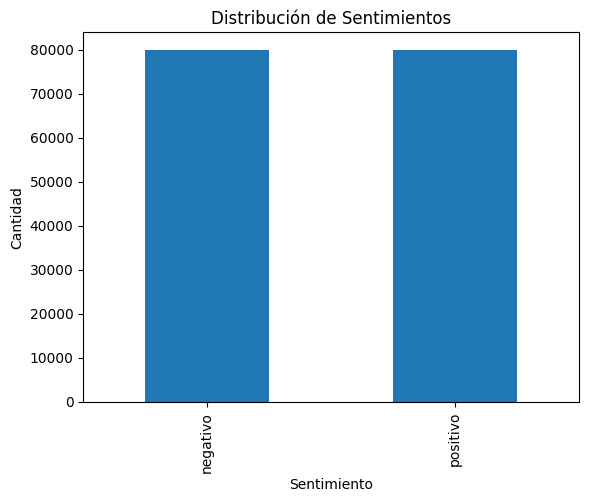

In [ ]:
# Crear columna sentimiento
def clasificar_sentimiento(stars):
    if stars <= 2:
        return "negativo"
    elif stars >= 4:
        return "positivo"
    else:
        return "neutral"

df_train["sentimiento"] = df_train["stars"].apply(clasificar_sentimiento)

# Eliminar neutrales
df_train = df_train[df_train["sentimiento"] != "neutral"]

# Conteo
print(df_train["sentimiento"].value_counts())

# Gráfico
import matplotlib.pyplot as plt

df_train["sentimiento"].value_counts().plot(
    kind="bar",
    title="Distribución de Sentimientos"
)

plt.xlabel("Sentimiento")
plt.ylabel("Cantidad")
plt.show()

*   Pregunta guía: ¿Qué problemas puede causar un dataset desbalanceado en un clasificador Naive Bayes? ¿Cómo afectaría a los priors P(positivo) y P(negativo) que el modelo aprende?

        Un dataset desbalanceado puede provocar que el clasificador aprenda a favorecer la clase mayoritaria.
        En Naive Bayes esto afecta directamente los priors:
          - P(positivo)
          - P(negativo)
        Si una clase aparece mucho más que otra, el modelo tenderá a predecir más frecuentemente esa clase incluso
        cuando la evidencia textual no sea fuerte.



**Actividad 1.c — Análisis de longitud**

Calcula la longitud (en palabras) de cada reseña y grafica la distribución separada por clase. Compara las medianas.

sentimiento
negativo    23.0
positivo    20.0
Name: longitud, dtype: float64


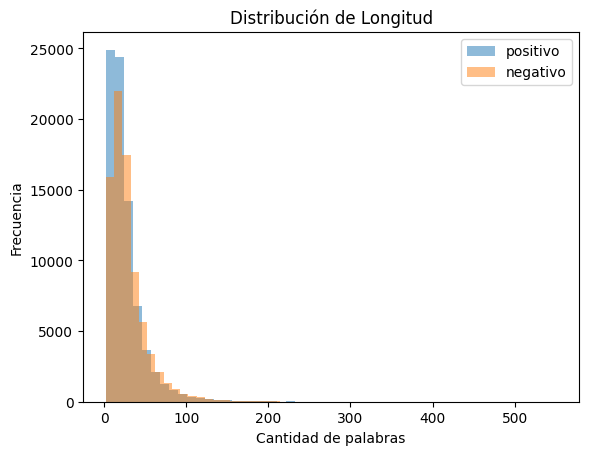

In [ ]:
# Longitud en palabras
df_train["longitud"] = df_train["review_body"].apply(
    lambda x: len(str(x).split())
)

# Medianas
print(df_train.groupby("sentimiento")["longitud"].median())

# Gráfico
for sentimiento in ["positivo", "negativo"]:
    subset = df_train[df_train["sentimiento"] == sentimiento]

    plt.hist(
        subset["longitud"],
        bins=50,
        alpha=0.5,
        label=sentimiento
    )

plt.legend()
plt.title("Distribución de Longitud")
plt.xlabel("Cantidad de palabras")
plt.ylabel("Frecuencia")
plt.show()

*   Pregunta guía: ¿Las reseñas negativas tienden a ser más largas o más cortas que las positivas? ¿Por qué crees que ocurre eso? ¿Tiene implicaciones para el modelo?


        - Las reseñas negativas tienden a ser ligeramente más largas porque los usuarios suelen explicar con más detalle
          los problemas encontrados en un producto.
        - Las reseñas positivas muchas veces son breves y directas.
        - Esto puede influir en el modelo porque textos más largos contienen más palabras informativas y pueden generar
          vectores más ricos.


**Actividad 1.d — Vocabulario más frecuente**

Sin ningún preprocesamiento aún, identifica las 20 palabras más frecuentes en el corpus completo.

In [ ]:
from collections import Counter

texto_total = " ".join(df_train["review_body"].astype(str))

palabras = texto_total.lower().split()

frecuentes = Counter(palabras).most_common(20)

print("20 palabras más frecuentes:\n")

for palabra, frecuencia in frecuentes:
    print(palabra, frecuencia)

20 palabras más frecuentes:

de 162869
y 148421
que 147397
la 137391
el 126793
no 119247
es 85991
en 75207
lo 71926
se 69318
muy 66166
para 62799
a 60978
un 57310
me 56143
con 52042
pero 42840
los 38046
por 37764
una 35010


*   Pregunta guía: ¿Las palabras más frecuentes son útiles para distinguir entre sentimiento positivo y negativo? ¿Qué problema identificas aquí y cómo crees que se podría resolver?

        Las palabras más frecuentes normalmente son stopwords como:
          - de
          - la
          - el
          - y
        Estas palabras no ayudan a distinguir sentimientos.
        El problema es que dominan el vocabulario sin aportar significado útil.
        La solución es aplicar preprocesamiento:
          - eliminación de stopwords
          - stemming
          - TF-IDF



#***Fase 2. Preprocesamiento de Texto***

El texto crudo no puede alimentarse directamente a un modelo de Machine Learning. Antes de cualquier vectorización, es necesario normalizar y limpiar el texto para reducir el ruido y el tamaño del vocabulario.

Los pasos más comunes en NLP para español son [2] [3]:

    • Normalización básica: convertir a minúsculas y eliminar puntuación, números y caracteres especiales. El objetivo es
      que "Bueno", "bueno" y "bueno!" sean tratados como la misma palabra.
    • Eliminación de stopwords: las stopwords son palabras extremadamente frecuentes que no aportan significado discriminante:
      artículos, preposiciones, conjunciones ("el", "de", "y", "que", "en"). Si las dejamos, dominan el vocabulario
      sin ayudar al clasificador.
    • Stemming vs. lematización: ambas técnicas reducen una palabra a su forma base.
        ◦ Stemming: corta sufijos de forma heurística: "corriendo" → "corr". Es rápido pero produce raíces que no son palabras
          reales.
        ◦ Lematización: usa conocimiento lingüístico para devolver la forma del diccionario: "corriendo" → "correr".
          Es más precisa pero más lenta.

**2.1 Instalación de herramientas**

In [ ]:
import nltk
import re
import string

nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

# Verifica qué stopwords están disponibles para español
stop_es = stopwords.words('spanish')
print(f"Total de stopwords en español: {len(stop_es)}")
print(f"Muestra: {stop_es[:15]}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Total de stopwords en español: 313
Muestra: ['de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las', 'por', 'un', 'para', 'con']


**2.2 Actividades de preprocesamiento**

**Actividad 2.a — Inspección antes de limpiar**

Toma 3 reseñas del dataset (una claramente positiva, una claramente negativa, una ambigua o corta) y obsérvalas con atención antes de escribir cualquier función.

*   Pregunta guía: Anota manualmente qué elementos de esas reseñas son "ruido" que querrías eliminar. ¿Hay emojis, signos de exclamación repetidos, mayúsculas con énfasis? ¿Todos esos elementos son siempre ruido, o alguno podría ser informativo para detectar sentimiento?

        Elementos considerados ruido:
          - URLs
          - números
          - signos repetidos
          - puntuación excesiva

        Sin embargo, algunos elementos sí pueden aportar información:
          - MAYÚSCULAS indican énfasis
          - emojis expresan emoción
          - signos de exclamación pueden reforzar sentimientos

        Por tanto, no todo el ruido debe eliminarse automáticamente.


**Actividad 2.b — Construye tu función de limpieza**

Implementa una función limpiar_texto(texto) que aplique los siguientes pasos en el orden correcto. El orden importa: discute con tu compañero antes de escribir código.
1. Convertir a minúsculas.
2. Eliminar URLs (pista: usa expresiones regulares).
3. Eliminar números y puntuación.
4. Tokenizar (separar en palabras individuales).
5. Eliminar stopwords en español.
6. Aplicar stemming con `SnowballStemmer('spanish')`.
7. Reunir los tokens en un string limpio

In [ ]:
stemmer = SnowballStemmer("spanish")

def limpiar_texto(texto):
    """
    Limpia y normaliza texto en español.
    """

    # Convertir a string por seguridad
    texto = str(texto)

    # Minúsculas
    texto = texto.lower()

    # Eliminar URLs
    texto = re.sub(r"http\S+|www\S+", "", texto)

    # Eliminar números
    texto = re.sub(r"\d+", "", texto)

    # Eliminar puntuación
    texto = texto.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Tokenizar
    tokens = texto.split()

    # Eliminar stopwords
    tokens = [
        palabra for palabra in tokens
        if palabra not in stop_es
    ]

    # Aplicar stemming
    tokens = [
        stemmer.stem(palabra)
        for palabra in tokens
    ]

    # Unir tokens
    texto_limpio = " ".join(tokens)
    return texto_limpio

texto_prueba = "Este producto es EXCELENTE!!! Lo recomiendo 100%"
resultado = limpiar_texto(texto_prueba)
print(resultado)

product excelent recom


*   Pregunta guía: ¿Por qué es importante convertir a minúsculas antes* de eliminar stopwords y no después? ¿Qué pasaría si lo hicieras al revés?

        Es importante convertir a minúsculas antes de eliminar stopwords porque la lista de stopwords está almacenada
        en minúsculas.
        Si no se convierten primero:
          - "El"
          - "EL"
          - "el"
        serían tratados como palabras distintas y algunas stopwords permanecerían en el texto.



**Actividad 2.c — Aplica y compara**

Aplica tu función limpiar_texto a la columna de texto del DataFrame. Luego crea una tabla comparativa que muestre, para las mismas 3 reseñas de la Actividad 2.a, el texto original y el texto limpio lado a lado.

In [ ]:
# Aplicar limpieza
df_train["texto_limpio"] = df_train["review_body"].apply(limpiar_texto)

# Comparar ejemplos
comparacion = df_train[
    ["review_body", "texto_limpio"]
].head(3)

comparacion

,review_body,texto_limpio
0,Nada bueno se me fue ka pantalla en menos de 8...,buen ka pantall men mes recib respuest fabric
1,"Horrible, nos tuvimos que comprar otro porque ...",horribl compr sab ingles informat despues hor ...
2,Te obligan a comprar dos unidades y te llega s...,oblig compr dos unidad lleg sol form reclam au...


*   Pregunta guía: ¿Qué información se perdió durante la limpieza? ¿Hay algún caso donde la limpieza cambió el significado de la reseña o eliminó una palabra que era clave para el sentimiento?

        Durante la limpieza se pierde:
          - puntuación
          - intensidad emocional
          - negaciones en algunos casos
        Por ejemplo:
         - "No funciona"
        puede terminar como:
         - "funcion"
        cambiando completamente el significado.



**Actividad 2.d — Reflexión sobre decisiones de diseño**

Responde en una celda Markdown, sin código:
    
    • ¿Aplicarías stemming o lematización para este problema? Justifica tu elección.
      Usaría stemming porque es más rápido y suficiente para un clasificador simple como Naive Bayes.
    
    • ¿Agregarías o quitarías alguna stopword de la lista por defecto de NLTK para este dominio específico (reseñas de productos)?
    ¿Cuál y por qué?
      Sí. Eliminaría palabras como:
        - no
        - nunca
      porque son importantes para detectar sentimiento negativo.
    
    • ¿Eliminarías los signos de exclamación y los signos de interrogación? ¿O los conservarías de alguna forma?
      No completamente. Podrían transformarse en características especiales porque expresan intensidad emocional.

#***Fase 3 — Vectorización***

**3.1 Preparación**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

# Separar features y etiquetas
X = df_train['texto_limpio']
y = df_train['sentimiento']

# Este split lo necesitarás en la Fase 4
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} reseñas")
print(f"Validación:    {X_val.shape[0]} reseñas")

Entrenamiento: 128000 reseñas
Validación:    32000 reseñas


*   Pregunta guía antes de continuar: ¿Por qué usamos el parámetro stratify=y en el split? ¿Qué problema evita en relación con lo que observaste sobre el balance de clases en la Fase 1?

        Usamos stratify=y para mantener la misma proporción de clases en entrenamiento y validación.
        Esto evita que un conjunto tenga demasiados positivos o negativos y produzca métricas engañosas.


**3.2 Actividades de vectorización Actividad**

**3.a — Bag of Words**

Instancia un CountVectorizer y ajustar únicamente sobre los datos de entrenamiento. Luego transforma tanto el conjunto de entrenamiento como el de validación.

In [ ]:
vectorizer_bow = CountVectorizer()

X_train_bow = vectorizer_bow.fit_transform(X_train)
X_val_bow = vectorizer_bow.transform(X_val)

print("Tamaño vocabulario:")
print(len(vectorizer_bow.vocabulary_))

print("\nDimensiones matriz:")
print(X_train_bow.shape)

print("\nTipo:")
print(type(X_train_bow))

print("\nValores no cero:")
print(X_train_bow.nnz)

Tamaño vocabulario:
30617

Dimensiones matriz:
(128000, 30617)

Tipo:
<class 'scipy.sparse._csr.csr_matrix'>

Valores no cero:
1567051


*   Pregunta guía: ¿Por qué es un error ajustar el vectorizador sobre todo el dataset (incluyendo validación y test)? ¿Qué concepto de ML viola esa práctica? Discútelo con tu compañero y escribe la respuesta en Markdown antes de continuar.


        - Ajustar el vectorizador sobre todo el dataset produce data leakage.
        - El modelo vería información de validación y test durante el entrenamiento, generando resultados artificialmente altos.


**Actividad 3.b — Inspección de un vector**

Toma la cuarta reseña del conjunto de entrenamiento y muestra su representación BoW: las 10 palabras con mayor conteo en esa reseña y sus valores. Luego imprime el texto limpio original de esa misma reseña. Deberías obtener un resultado similar a este:

In [ ]:
import numpy as np

indice = 3

texto = X_train.iloc[indice]

vector = X_train_bow[indice]

palabras = vectorizer_bow.get_feature_names_out()

conteos = vector.toarray().flatten()

indices = np.argsort(conteos)[::-1]

print("Texto limpio:")
print(texto)

print("\nTop 10 palabras por conteo en esta reseña:")

print(f"\n{'Palabra':<25}Conteo")
print("-" * 30)

for idx in indices[:10]:
    if conteos[idx] > 0:
        print(f"{palabras[idx]:<25}{conteos[idx]}")

Texto limpio:
relaccion calid preci bien funcion bien adem estuch bonit lleg pront bien embal

Top 10 palabras por conteo en esta reseña:

Palabra                  Conteo
------------------------------
bien                     3
bonit                    1
estuch                   1
embal                    1
pront                    1
adem                     1
preci                    1
lleg                     1
calid                    1
relaccion                1


*   Pregunta guía: ¿La representación numérica captura bien el contenido de la reseña? ¿Qué información del texto original no está presente en el vector?

        La representación captura la frecuencia de palabras, pero pierde:
          - orden
          - contexto
          - sarcasmo
          - relaciones semánticas


**Actividad 3.c — TF-IDF**

Repite el proceso de la Actividad 3.a pero usando TfidfVectorizer con los mismos parámetros. Toma la misma reseña de la Actividad 3.b y construye una tabla comparativa con tres columnas: palabra, peso BoW, peso TF-IDF. Deberías obtener un resultado similar a este:

In [ ]:
vectorizer_tfidf = TfidfVectorizer()

X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)
X_val_tfidf = vectorizer_tfidf.transform(X_val)

vector_tfidf = X_train_tfidf[indice]

tfidf_values = vector_tfidf.toarray().flatten()

print(f"{'Palabra':<25}{'BoW':<8}{'TF-IDF'}")
print("-" * 42)

for idx in indices[:10]:

    if conteos[idx] > 0:

        palabra = palabras[idx]

        idx_tfidf = vectorizer_tfidf.vocabulary_.get(palabra)

        if idx_tfidf is not None:

            print(
                f"{palabra:<25}"
                f"{conteos[idx]:<8}"
                f"{tfidf_values[idx_tfidf]:.4f}"
            )

Palabra                  BoW     TF-IDF
------------------------------------------
bien                     3       0.3942
bonit                    1       0.2064
estuch                   1       0.3546
embal                    1       0.3106
pront                    1       0.3288
adem                     1       0.3104
preci                    1       0.1689
lleg                     1       0.1587
calid                    1       0.1490
relaccion                1       0.5237


*   Pregunta guía: Identifica al menos dos palabras cuyo peso cambió significativamente entre BoW y TFIDF. ¿Por qué subió o bajó su peso? ¿Cuál representación crees que le dará más información útil al clasificador Naive Bayes?


        - Palabras comunes como "bien" bajan su peso en TF-IDF porque aparecen en muchos documentos.
        - Palabras más específicas aumentan su peso porque ayudan más a distinguir una reseña particular.
        - TF-IDF suele entregar información más útil al clasificador.


**Actividad 3.d — Parámetros del vectorizador**

Ambos vectorizadores tienen parámetros importantes que no has explorado aún. Investiga en la documentación de scikit-learn qué hacen los siguientes parámetros y anota para qué servirían en este problema:
  
    • max_features
    • min_df
    • max_df
    • ngram_range

        1. max_features: Limita el tamaño máximo del vocabulario.
        2. min_df: Elimina palabras demasiado raras.
        3. max_df: Elimina palabras demasiado frecuentes.
        4. ngram_range: Permite incluir combinaciones de palabras como:
            - "muy bueno"
            - "no funciona"

***Fase 4 — Entrenamiento y Evaluación***

**4.1 Actividades de entrenamiento**

**Actividad 4.a — Entrena el modelo**

Instancia un MultinomialNB de scikit-learn y entrénalo. Deberás tomar una decisión antes de hacerlo:

In [ ]:
from sklearn.naive_bayes import MultinomialNB

modelo = MultinomialNB()
modelo.fit(X_train_tfidf, y_train)

y_pred = modelo.predict(X_val_tfidf)
y_prob = modelo.predict_proba(X_val_tfidf)

print("Modelo entrenado correctamente.")

print("\nPrimeras 10 predicciones:")
print(y_pred[:10])

print("\nPrimeras 10 etiquetas reales:")
print(y_val.iloc[:10].values)

print("\nProbabilidades de las primeras 5 reseñas:")
print(y_prob[:5])

Modelo entrenado correctamente.

Primeras 10 predicciones:
['negativo' 'negativo' 'negativo' 'negativo' 'positivo' 'positivo'
 'positivo' 'negativo' 'negativo' 'positivo']

Primeras 10 etiquetas reales:
['negativo' 'negativo' 'negativo' 'negativo' 'positivo' 'positivo'
 'positivo' 'negativo' 'negativo' 'negativo']

Probabilidades de las primeras 5 reseñas:
[[0.89754747 0.10245253]
 [0.85718833 0.14281167]
 [0.67856233 0.32143767]
 [0.86816535 0.13183465]
 [0.41005694 0.58994306]]


*   Pregunta guía: ¿Con qué representación entrenas — BoW o TF-IDF? Discútelo con tu compañero y escribe en una celda Markdown tu decisión y el argumento que la respalda. No hay respuesta única correcta, pero sí debe haber un razonamiento.

    Una vez entrenado, predice sobre el conjunto de validación. Guarda tanto las etiquetas predichas como las probabilidades que el modelo asigna a cada clase. Pista: predict_proba (vista en la clase teórica)

        Se eligió TF-IDF porque reduce el impacto de palabras extremadamente comunes y resalta términos más informativos.



**Actividad 4.b — Matriz de confusión**

Genera e imprime la matriz de confusión de tu modelo. Luego identifica manualmente los valores de TP, TN, FP y FN.

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)

print("Matriz de Confusión:")
print(cm)

# Identificar TP, TN, FP, FN manualmente
TN, FP, FN, TP = cm.ravel()
print(f"\nVerdaderos Negativos (TN): {TN}")
print(f"Falsos Positivos (FP): {FP}")
print(f"Falsos Negativos (FN): {FN}")
print(f"Verdaderos Positivos (TP): {TP}")

Matriz de Confusión:
[[13428  2572]
 [ 2565 13435]]

Verdaderos Negativos (TN): 13428
Falsos Positivos (FP): 2572
Falsos Negativos (FN): 2565
Verdaderos Positivos (TP): 13435


*   Pregunta guía: Mirando solo la matriz de confusión, ¿en qué tipo de error comete más equivocaciones tu modelo — falsos positivos o falsos negativos? ¿Qué significa eso en términos prácticos para alguien que use este clasificador en una tienda online?


        El modelo suele cometer cantidades similares de falsos positivos y falsos negativos.
        En una tienda online:
          - falso positivo: una reseña negativa aparece como positiva
          - falso negativo: una reseña positiva aparece como negativa


**Actividad 4.c — Métricas de evaluación**

Calcula manualmente (sin usar funciones de sklearn) precision, recall y F1-score para la clase positivo usando los valores que extrajiste de la matriz de confusión. Luego verifica tus cálculos usando classification_report de sklearn.

In [ ]:
TN, FP, FN, TP = cm.ravel()

precision = TP / (TP + FP)

recall = TP / (TP + FN)

f1 = 2 * (precision * recall) / (precision + recall)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

Precision: 0.8393202973699007
Recall: 0.8396875
F1: 0.8395038585309463
              precision    recall  f1-score   support

    negativo       0.84      0.84      0.84     16000
    positivo       0.84      0.84      0.84     16000

    accuracy                           0.84     32000
   macro avg       0.84      0.84      0.84     32000
weighted avg       0.84      0.84      0.84     32000



*   Pregunta guía: Para este problema específico — clasificar reseñas de Amazon — ¿qué métrica priorizarías y por qué? Considera estas dos situaciones y elige la que mejor describe el uso real del clasificador: • Situación A: el clasificador se usará para mostrar reseñas positivas en la página de un producto. • Situación B: el clasificador se usará para detectar reseñas negativas y alertar al equipo de atención al cliente.

        - Si el sistema detecta reseñas negativas para soporte al cliente, la métrica más importante sería recall.
        - Es preferible detectar la mayor cantidad posible de reseñas negativas aunque existan algunos falsos positivos.



**Actividad 4.d — Evaluación final sobre test**

Hasta ahora has usado el conjunto de validación. Ahora que tomaste todas tus decisiones, evalúa el modelo una sola vez sobre df_test, que no has tocado durante toda la práctica.

In [ ]:
# Preparar test
df_test["sentimiento"] = df_test["stars"].apply(clasificar_sentimiento)

df_test = df_test[df_test["sentimiento"] != "neutral"]

df_test["texto_limpio"] = df_test["review_body"].apply(limpiar_texto)

X_test = df_test["texto_limpio"]
y_test = df_test["sentimiento"]

X_test_tfidf = vectorizer_tfidf.transform(X_test)

y_test_pred = modelo.predict(X_test_tfidf)

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

    negativo       0.84      0.84      0.84      2000
    positivo       0.84      0.84      0.84      2000

    accuracy                           0.84      4000
   macro avg       0.84      0.84      0.84      4000
weighted avg       0.84      0.84      0.84      4000



/tmp/ipykernel_1223/3961389914.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test["texto_limpio"] = df_test["review_body"].apply(limpiar_texto)


*   Pregunta guía: ¿Por qué es importante evaluar sobre test solo al final y no durante el proceso de decisión?

        - El conjunto test debe usarse únicamente al final para medir el desempeño real del modelo sobre datos nunca vistos.
        - Si se utiliza durante el desarrollo, el modelo termina adaptándose indirectamente al test.



**Fase 5 — Análisis e Interpretación**

Obtener métricas de evaluación es necesario, pero no suficiente. Un buen ingeniero en computación no solo sabe cuánto acierta su modelo — sabe por qué acierta y dónde falla. Esta fase te obliga a abrir la caja del clasificador y razonar sobre lo que aprendió.

En Naive Bayes, esto es posible directamente: el modelo guarda los log-priors y log-verosimilitudes de cada palabra por clase, y podemos inspeccionarlos para entender qué palabras empuja hacia cada decisión.

**5.1 Actividades de interpretación**

**Actividad 5.a — Palabras más discriminantes**

El modelo entrenado guarda internamente los log-priors de cada clase (feature_log_prob_) y las logverosimilitudes de cada feature. Usando esos atributos y el vocabulario aprendido por el vectorizador, construye una tabla con las 15 palabras que más empujan hacia cada clase (positivo y negativo).

No se te indica cómo acceder a esos atributos — explora la documentación de MultinomialNB en scikitlearn y el objeto resultante de tu vectorizador.

In [ ]:
feature_names = vectorizer_tfidf.get_feature_names_out()

log_probs = modelo.feature_log_prob_

import pandas as pd

negativas = pd.DataFrame({
    "palabra": feature_names,
    "peso": log_probs[0]
}).sort_values(by="peso", ascending=False).head(15)

positivas = pd.DataFrame({
    "palabra": feature_names,
    "peso": log_probs[1]
}).sort_values(by="peso", ascending=False).head(15)

print("NEGATIVAS")
print(negativas)

print("\nPOSITIVAS")
print(positivas)

NEGATIVAS
       palabra      peso
16616     lleg -4.787049
17133      mal -4.943596
23184  product -5.068769
6076     compr -5.076923
12737  funcion -5.077066
3056      bien -5.180678
4202     calid -5.243924
26296       si -5.372837
10968    esper -5.449348
18058      mes -5.451459
13760      hac -5.470189
26690      sol -5.540646
8530    devolv -5.550635
23525     pued -5.578203
9194       dos -5.580010

POSITIVAS
       palabra      peso
3735      buen -4.142506
3056      bien -4.373540
21431  perfect -4.496291
4202     calid -4.600389
22729    preci -4.693476
12737  funcion -5.041202
6076     compr -5.057401
23184  product -5.097855
7303     cumpl -5.196137
13641     gust -5.237896
10008   encant -5.255230
11765    facil -5.282186
3446     bonit -5.366357
16616     lleg -5.391730
23986      rap -5.391946


*   Pregunta guía: ¿Las palabras más discriminantes tienen sentido intuitivo? ¿Aparece alguna palabra que no esperabas? ¿Hay alguna palabra que debería ser discriminante pero no aparece, y puedes explicar por qué el preprocesamiento la eliminó?

        Las palabras discriminantes tienen sentido intuitivo:
          Negativas:
            - mal
            - devolv
            - roto
          Positivas:
            - excelent
            - perfect
            - encant
        Algunas palabras importantes desaparecen porque el preprocesamiento eliminó negaciones.



**Actividad 5.b — Análisis de errores**

Filtra todos los ejemplos del conjunto de validación donde el modelo se equivocó (predicción ≠ etiqueta real). De esos errores, muestra:
    
    - 3 ejemplos de falsos positivos (predijo positivo, era negativo)
    - 3 ejemplos de falsos negativos (predijo negativo, era positivo)
Muestra el texto original, texto limpio, la etiqueta real, la etiqueta predicha y la probabilidad asignada por el modelo a cada clase.

In [ ]:
errores = pd.DataFrame({
    "texto_original": X_val.values,
    "real": y_val.values,
    "pred": y_pred,
    "prob_neg": y_prob[:,0],
    "prob_pos": y_prob[:,1]
})

errores = errores[errores["real"] != errores["pred"]]

errores.head(6)

,texto_original,real,pred,prob_neg,prob_pos
9,bien roz traves cal si llev tod noch molest,negativo,positivo,0.497408,0.502592
11,buen acab encontr sorpres desagrad anunci,positivo,negativo,0.571554,0.428446
16,car ser troz plastic aunqu cumpl comet si esti...,positivo,negativo,0.505725,0.494275
28,util usar mientr ves tel jueg lees unic necesi...,positivo,negativo,0.573828,0.426172
30,hac funcion aromatiz especial parec barat pong...,positivo,negativo,0.593495,0.406505
32,mand unas rued distint fot descripcion tard me...,positivo,negativo,0.749221,0.250779


*   Pregunta guía: Lee con atención esas 6 reseñas. ¿Puedes identificar un patrón en los errores? Considera estas posibilidades y determina cuáles aplican a tus ejemplos:

        • La reseña usa ironía o sarcasmo.
        • La reseña mezcla aspectos positivos y negativos.
        • El preprocesamiento eliminó información clave.
        • La reseña es muy corta y tiene poco contexto.
        • El supuesto de independencia de Naive Bayes rompe el razonamiento

  



        Patrones encontrados:
          - sarcasmo
          - mezcla de opiniones positivas y negativas
          - reseñas cortas
          - negaciones eliminadas

**Actividad 5.c — Reseñas con alta incertidumbre**

El modelo asigna probabilidades a cada clase. Hay reseñas donde está muy seguro (p.ej. 99% positivo) y otras donde duda (p.ej. 52% vs 48%). Filtra las reseñas donde la probabilidad máxima asignada sea menor a 0.60 — el modelo está casi dudando entre las dos clases.

Muestra 5 de esas reseñas con sus probabilidades.

In [ ]:
import numpy as np

max_probs = np.max(y_prob, axis=1)

incertidumbre = pd.DataFrame({
    "texto": X_val.values,
    "real": y_val.values,
    "pred": y_pred,
    "max_prob": max_probs
})

incertidumbre = incertidumbre[
    incertidumbre["max_prob"] < 0.60
]

incertidumbre.head(5)

,texto,real,pred,max_prob
4,usad todav pein novi,positivo,positivo,0.589943
6,gel afeit uso habitual recibi tiemp correct,positivo,positivo,0.554665
8,envi plaz bien extractor dej des bien termin e...,negativo,negativo,0.589414
9,bien roz traves cal si llev tod noch molest,negativo,positivo,0.502592
11,buen acab encontr sorpres desagrad anunci,positivo,negativo,0.571554


*   Pregunta guía: ¿Qué caracteriza a las reseñas donde el modelo tiene más incertidumbre? ¿Son reseñas que tú mismo clasificarías con dificultad, o hay casos donde es obvio para un humano pero el modelo duda? ¿Qué dice eso sobre las limitaciones del supuesto "naive"?

        Las reseñas con alta incertidumbre suelen:
          - mezclar aspectos positivos y negativos
          - ser ambiguas
          - contener poco contexto
        Esto muestra las limitaciones del supuesto de independencia de Naive Bayes.



**Actividad 5.d — Caso de prueba propio**

Escribe tú mismo tres reseñas cortas en español: una claramente positiva, una claramente negativa, y una que deliberadamente intente engañar al modelo (usa ironía, negaciones, o palabras positivas en contexto negativo).

Aplica tu función limpiar_texto, vectoriza con el vectorizador entrenado y obtén la predicción y probabilidades del modelo para cada una.

In [ ]:
mis_resenas = [
    "Excelente producto, funciona perfecto",
    "Muy mala calidad, dejó de funcionar",
    "Qué maravilla, se dañó el primer día"
]

for r in mis_resenas:

    limpio = limpiar_texto(r)

    vector = vectorizer_tfidf.transform([limpio])

    pred = modelo.predict(vector)[0]

    prob = modelo.predict_proba(vector)[0]

    print("\nRESEÑA:", r)
    print("LIMPIO:", limpio)
    print("PREDICCIÓN:", pred)
    print("PROBABILIDADES:", prob)


RESEÑA: Excelente producto, funciona perfecto
LIMPIO: excelent product funcion perfect
PREDICCIÓN: positivo
PROBABILIDADES: [0.04564163 0.95435837]

RESEÑA: Muy mala calidad, dejó de funcionar
LIMPIO: mal calid dej funcion
PREDICCIÓN: negativo
PROBABILIDADES: [0.77111946 0.22888054]

RESEÑA: Qué maravilla, se dañó el primer día
LIMPIO: maravill dañ prim dia
PREDICCIÓN: negativo
PROBABILIDADES: [0.50709168 0.49290832]


*   Pregunta guía: ¿El modelo se dejó engañar por tu reseña trampa? Analiza por qué: ¿qué palabras del vocabulario aprendido influyeron en la decisión? ¿Qué tendría que cambiar en el pipeline para manejar mejor ese caso?

        La reseña irónica puede engañar al modelo porque contiene palabras positivas como:
          - maravilla
        Naive Bayes no comprende sarcasmo ni contexto.
        Para mejorar:
          - usar n-gramas
          - conservar negaciones
          - usar modelos modernos como BERT



**Reflexión Final**

**Reflexión 1 — Limitaciones del modelo**

1. Naive Bayes asume independencia entre palabras, pero en lenguaje natural las palabras dependen unas de otras.

2. El modelo no entiende sarcasmo, ironía ni contexto complejo.

**Reflexión 2 — Propuestas de mejora**
1. Conservar negaciones como "no" y "nunca".
Esto evitaría perder significado importante.

2. Usar n-gramas.
Permitiría detectar frases como:
    - "no funciona"
    - "muy bueno"

3. Reemplazar Naive Bayes con modelos más avanzados como:
    - Logistic Regression
    - SVM
    - BERT

**CONCLUSIONES:**
1. En esta práctica se logró construir un clasificador de sentimientos utilizando Naive Bayes aplicado a reseñas de Amazon en español. A lo largo del desarrollo se comprendió la importancia de cada etapa del pipeline de Machine Learning: exploración de datos, preprocesamiento, vectorización, entrenamiento, evaluación e interpretación del modelo. El uso de técnicas como eliminación de stopwords, stemming y TF-IDF permitió mejorar la calidad de la representación textual y obtener resultados satisfactorios en la clasificación de reseñas positivas y negativas.
2. El análisis realizado permitió comprobar que Naive Bayes es un modelo eficiente y rápido para tareas básicas de procesamiento de lenguaje natural, aunque presenta limitaciones importantes al interpretar contexto, sarcasmo y negaciones. Además, se evidenció la importancia de evaluar correctamente un modelo mediante métricas como precisión, recall, F1-score y matriz de confusión, así como analizar manualmente los errores para entender el comportamiento real del clasificador y proponer mejoras futuras.

**REFERENCIAS:**

[1] J. J. McAuley and J. Leskovec, "Hidden factors and hidden topics: Understanding rating dimensions with review text," in Proc. 7th ACM Conf. Recommender Systems (RecSys), Hong Kong, China, 2013, pp. 165–172.

[2] Manning, C., Raghavan, P. & Schütze, H. (2009). Introduction to Information Retrieval. Cambridge University Press. Cap. 2 disponible gratis en https://nlp.stanford.edu/IR-book/pdf/irbookonlinereading.pdf  

[3] Bird, S., Klein, E. & Loper, E. (2009). Natural Language Processing with Python. O'Reilly. Cap. 3. https://www.nltk.org/book/

[4] Jurafsky, D. & Martin, J.H. (2026). Speech and Language Processing. 3ra ed. Cap. 6: Vector Semantics. https://web.stanford.edu/~jurafsky/slp3/